# GTO interface
We need to build an interface, because with the use of simply primitives, it is very cumbersome to work. Therefore, we are going to build an enhanced GTOClass, that handles with the angular momentum not efficienty, but less problematically. 

In [1]:
from py_mods.src.integrals.GTO import GTO, create_normalized_GTO, generate_angular_momentum_projections, S_3D, T_3D, V_3D, eri
from py_mods.src.SCF.plot_utilities import plot_map
from dataclasses import dataclass

We start defining the `GTOClass` with:  

In [2]:
from numpy.typing import NDArray
import numpy as np 

@dataclass
class CGTOClass:
    R: NDArray[np.float64] # position of the basis
    exps: NDArray[np.float64] # exponents
    N_a: float # normalization constant
    d_i: NDArray[np.float64] # contraction coefficients
    total_l: int
    l_dim: int # number of projections with this angular momentum
    l_projections: NDArray[np.int32] # all the projections for this angular momentum
    primitives: list[GTO] # we actually need these because of the normalization constants


We need to generate a factory method again:

In [3]:
def create_CGTOClass(
    R: NDArray[np.float64],
    exps: NDArray[np.float64],
    d_i: NDArray[np.float64],
    total_L: int,
) -> CGTOClass:
    """
    Factory function to create a GTOClass 

    Parameters
    ----------
    R : NDArray[np.float64]
        Center of the GTO.
    exps : NDArray[np.float64]
        Exponents of the primitives.
    d_i : NDArray[np.float64]
        Contraction coefficients of the primitives.
    total_L : int
        Total angular momentum of the GTO.

    Returns
    -------
    GTOClass
        The constructed GTOClass object.
    """
    l_projections = generate_angular_momentum_projections(total_L)
    l_dim = l_projections.shape[0]
    primitives = [create_normalized_GTO(R, exp, total_L) for exp in exps]
    

    unnormalized_cgto =  CGTOClass(
        R=R,
        exps=exps,
        d_i=d_i,
        N_a=1,
        total_l=total_L,
        l_dim=l_dim,
        l_projections=l_projections,
        primitives=primitives,
    )

    N_a = calculate_normalization_constant(unnormalized_cgto)

    unnormalized_cgto.N_a = N_a

    return unnormalized_cgto


def S_GTO_proj(cont_1: CGTOClass, proj_idx_1: int, cont_2: CGTOClass, proj_idx_2: int):
    """


    """
    projection_vec_1 = cont_1.l_projections[proj_idx_1]
    projection_vec_2 = cont_2.l_projections[proj_idx_2]

    S: float = 0.0
    for i, gto_1 in enumerate(cont_1.primitives):
        for j, gto_2 in enumerate(cont_2.primitives):
            N_a = gto_1.normalization_constants[proj_idx_1]
            N_b = gto_2.normalization_constants[proj_idx_2]
            primitive_overlap = (
                cont_1.d_i[i]
                * cont_2.d_i[j]
                * S_3D(
                    gto_1,
                    projection_vec_1,
                    N_a,
                    gto_2,
                    projection_vec_2,
                    N_b,
                )
            )

            S += primitive_overlap

    return S

def calculate_normalization_constant(cont: CGTOClass) -> float:
    """


    """
    S = S_GTO_proj(cont, 0, cont, 0)
    N = 1.0 / np.sqrt(S)

    return N

def S_GTO_mat(cont_1: CGTOClass, cont_2: CGTOClass):
    """
    """
    S_mat = np.zeros((cont_1.l_dim, cont_2.l_dim))
    
    for p1 in range(cont_1.l_dim):
        for p2 in range(cont_1.l_dim):
            S_mat[p1, p2] = S_GTO_proj(cont_1, p1, cont_2, p2)
            
    return S_mat * cont_1.N_a * cont_2.N_a

Lets build an uncontracted GTO of s and p type centered at different positions:

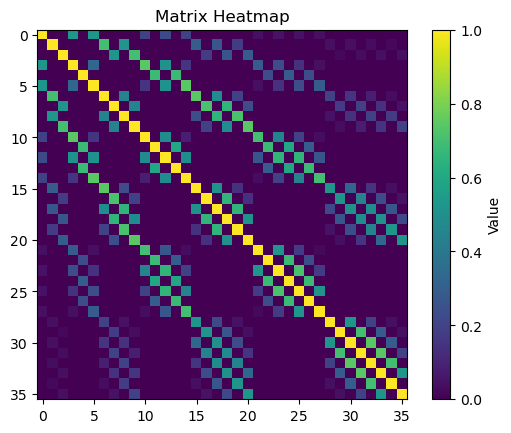

In [4]:
He_test = create_CGTOClass(np.array([0,0,0]), np.array([0.5, 0.2]), np.array([1.0, 1]), 7)
S_test = S_GTO_mat(He_test, He_test)
plot_map(S_test)

There are 3 l_projs


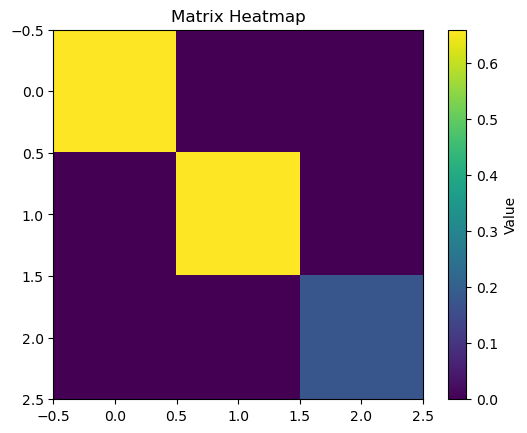

In [5]:
#STO3g example:
l = 1
l_tags = ['S', 'P', 'D', 'F', 'G', 'H']
l_projs = len(generate_angular_momentum_projections(l))
print(f"There are {l_projs} l_projs")

r1 = np.array([0.0, 0.0, 0.0])
r2 = np.array([0.0, 0.0, 1.4])
H_exps = np.array([3.42525091, 0.62391373, 0.16885540])
H_coeffs = np.array([0.15432897, 0.53532814, 0.44463454])

# Construct the CGTO 
H_1s_1 = create_CGTOClass(r1, H_exps, H_coeffs, l)
H_1s_2 = create_CGTOClass(r2, H_exps, H_coeffs, l)

S_1s1s_sto3g_self = S_GTO_mat(H_1s_1, H_1s_2)
plot_map(S_1s1s_sto3g_self)

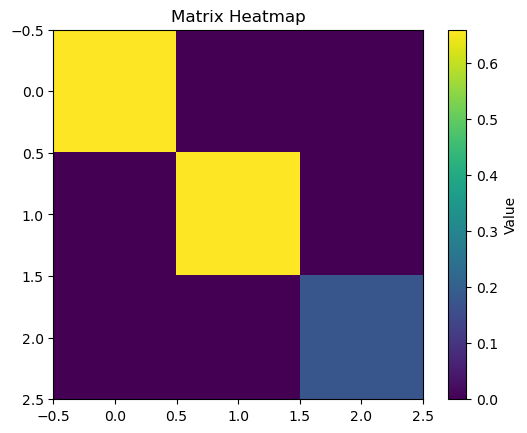

In [6]:
from pyscf import gto
mol = gto.M(
    atom = 'H 0 0 0; H 0 0 1.4',
    unit = 'Bohr', 
    basis = {'H': gto.basis.parse(f'''
        # This is the standard STO-3G definition
        # Exponent    Contraction Coeff
        H {l_tags[l]}
        3.42525091    0.15432897
        0.62391373    0.53532814
        0.16885540    0.44463454
    ''')},
    cart=True,
)

mol.build()


overlap = mol.intor('int1e_ovlp')
kin = mol.intor('int1e_kin')
V = mol.intor('int1e_nuc')
ref_eri = mol.intor('int2e')

#pyscf does not normalize in cartesian like this, we have to renormalize to compare
norm_vec = 1.0 / np.sqrt(np.diag(overlap))

overlap *= norm_vec[:, None] 
overlap *= norm_vec[None, :]

kin *= norm_vec[:, None]
kin *= norm_vec[None, :]

V *= norm_vec[:, None] 
V *= norm_vec[None, :]

ref_eri *= norm_vec[:, None, None, None]
ref_eri *= norm_vec[None, :, None, None]
ref_eri *= norm_vec[None, None, :, None]
ref_eri *= norm_vec[None, None, None, :]

plot_map(overlap[l_projs:,:l_projs])

Which seems to work

---

# $T$ integrals of CGTO
now lets try to replicate the same but for the kinetic energy matrix elements

In [7]:
def T_GTO_mat(cont_1: CGTOClass, cont_2: CGTOClass):
    """
    """
    S_mat = np.zeros((cont_1.l_dim, cont_2.l_dim))
    
    for p1 in range(cont_1.l_dim):
        for p2 in range(cont_1.l_dim):
            S_mat[p1, p2] = T_GTO_proj(cont_1, p1, cont_2, p2)
            
    return S_mat * cont_1.N_a * cont_2.N_a



def T_GTO_proj(cont_1: CGTOClass, proj_idx_1: int, cont_2: CGTOClass, proj_idx_2: int):
    """


    """
    projection_vec_1 = cont_1.l_projections[proj_idx_1]
    projection_vec_2 = cont_2.l_projections[proj_idx_2]

    S: float = 0.0
    for i, gto_1 in enumerate(cont_1.primitives):
        for j, gto_2 in enumerate(cont_2.primitives):
            N_a = gto_1.normalization_constants[proj_idx_1]
            N_b = gto_2.normalization_constants[proj_idx_2]
            primitive_overlap = (
                cont_1.d_i[i]
                * cont_2.d_i[j]
                * T_3D(
                    gto_1,
                    projection_vec_1,
                    N_a,
                    gto_2,
                    projection_vec_2,
                    N_b,
                )
            )

            S += primitive_overlap

    return S

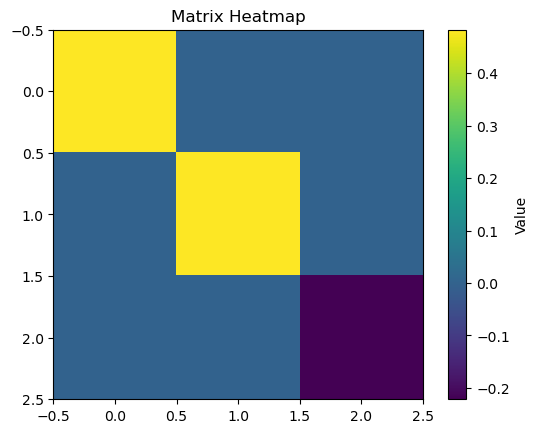

In [8]:
T_1s1s_sto3g_self = T_GTO_mat(H_1s_1, H_1s_2)
plot_map(T_1s1s_sto3g_self)

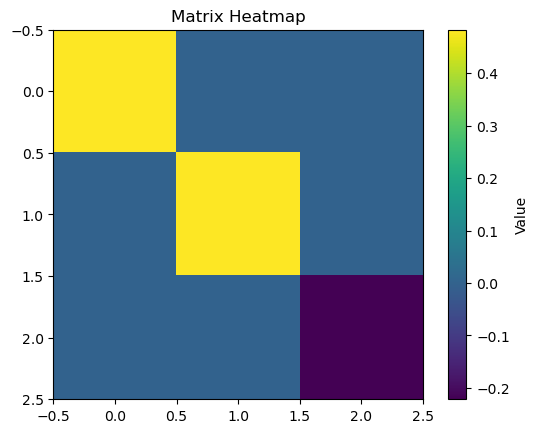

In [9]:
plot_map(kin[l_projs:, :l_projs])

Which seems to work

---

# $V$ matrix elements in CGTOs

Lets try to repeat once again the previous:

In [10]:
def V_GTO_mat_all_atoms(cont_1: CGTOClass, cont_2: CGTOClass, atom_pos, atom_charges):
    """
    """
    S_mat = np.zeros((cont_1.l_dim, cont_2.l_dim))
    
    for p1 in range(cont_1.l_dim):
        for p2 in range(cont_1.l_dim):
            S_mat[p1, p2] = V_GTO_proj(cont_1, p1, cont_2, p2, atom_pos, atom_charges)
            
    return S_mat * cont_1.N_a * cont_2.N_a



def V_GTO_proj(cont_1: CGTOClass, proj_idx_1: int, cont_2: CGTOClass, proj_idx_2: int, atom_pos, atom_charges):
    """


    """
    if len(atom_pos) != len(atom_charges):
        raise ValueError("atom_pos and atom_charges must have the same length.")

    projection_vec_1 = cont_1.l_projections[proj_idx_1]
    projection_vec_2 = cont_2.l_projections[proj_idx_2]

    S: float = 0.0
    for i, gto_1 in enumerate(cont_1.primitives):
        for j, gto_2 in enumerate(cont_2.primitives):
            for a in range(len(atom_charges)):
                pos = atom_pos[a]
                charge = atom_charges[a]
                N_a = gto_1.normalization_constants[proj_idx_1]
                N_b = gto_2.normalization_constants[proj_idx_2]
                primitive_overlap = (
                    cont_1.d_i[i]
                    * cont_2.d_i[j]
                    * V_3D(
                        gto_1,
                        projection_vec_1,
                        N_a,
                        gto_2,
                        projection_vec_2,
                        N_b,
                        charge,
                        pos
                    )
                )

                S += primitive_overlap

    return S

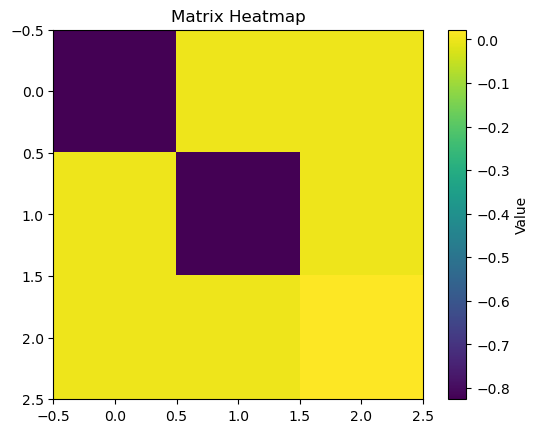

In [11]:
atom_pos = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 1.4]])
atom_charges = np.array([1.,1.])
V_1s1s_sto3g_self = V_GTO_mat_all_atoms(H_1s_1, H_1s_2, atom_pos, atom_charges)

plot_map(V_1s1s_sto3g_self)

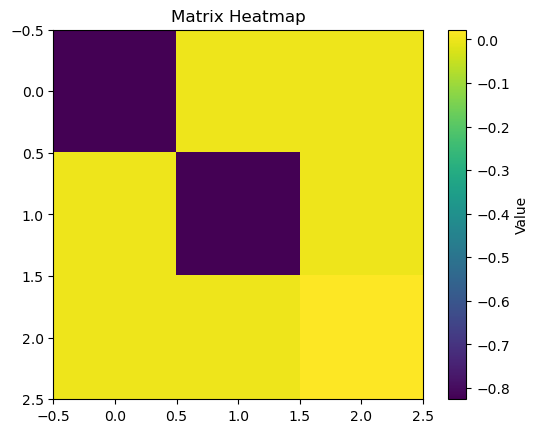

In [12]:
plot_map(V[l_projs:, :l_projs])

Which seems to work too. 

---

# ERIs in CGTOs
Finally, let's try to do the same once again with CGTOs. It is a little different because of the four center integrals, but the idea is the same.

In [13]:
def Eri_GTO_tensor(
    cont_1: CGTOClass, cont_2: CGTOClass, cont_3: CGTOClass, cont_4: CGTOClass
):
    """ """
    S_mat = np.zeros((cont_1.l_dim, cont_2.l_dim, cont_3.l_dim, cont_4.l_dim))

    for p1 in range(cont_1.l_dim):
        for p2 in range(cont_1.l_dim):
            for p3 in range(cont_3.l_dim):
                for p4 in range(cont_4.l_dim):
                    S_mat[p1, p2, p3, p4] = eri_GTO_proj(
                        cont_1, p1, cont_2, p2, cont_3, p3, cont_4, p4
                    )

    return S_mat * cont_1.N_a * cont_2.N_a * cont_3.N_a * cont_4.N_a


def eri_GTO_proj(
    cont_1: CGTOClass,
    proj_idx_1: int,
    cont_2: CGTOClass,
    proj_idx_2: int,
    cont_3: CGTOClass,
    proj_idx_3: int,
    cont_4: CGTOClass,
    proj_idx_4: int,
):
    """ """
    projection_vec_1 = cont_1.l_projections[proj_idx_1]
    projection_vec_2 = cont_2.l_projections[proj_idx_2]
    projection_vec_3 = cont_3.l_projections[proj_idx_3]
    projection_vec_4 = cont_4.l_projections[proj_idx_4]

    S: float = 0.0
    for i, gto_1 in enumerate(cont_1.primitives):
        for j, gto_2 in enumerate(cont_2.primitives):
            for k, gto_3 in enumerate(cont_3.primitives):
                for l, gto_4 in enumerate(cont_4.primitives):
                    N_a = gto_1.normalization_constants[proj_idx_1]
                    N_b = gto_2.normalization_constants[proj_idx_2]
                    N_c = gto_3.normalization_constants[proj_idx_3]
                    N_d = gto_4.normalization_constants[proj_idx_4]

                    primitive_overlap = (
                        cont_1.d_i[i]
                        * cont_2.d_i[j]
                        * cont_3.d_i[k]
                        * cont_4.d_i[l]
                        * eri(
                            gto_1,
                            projection_vec_1,
                            N_a,
                            gto_2,
                            projection_vec_2,
                            N_b,
                            gto_3,
                            projection_vec_3,
                            N_c,
                            gto_4,
                            projection_vec_4,
                            N_d,
                        )
                    )

                    S += primitive_overlap

    return S

In [14]:
Eri_test = Eri_GTO_tensor(H_1s_1, H_1s_1, H_1s_1, H_1s_1)
print(np.allclose(Eri_test, ref_eri[l_projs:,l_projs:,l_projs:,l_projs:]))

True


In [15]:
Eri_test = Eri_GTO_tensor(H_1s_2, H_1s_2, H_1s_1, H_1s_1)
print(np.allclose(Eri_test, ref_eri[:l_projs,:l_projs,l_projs:,l_projs:]))

True


In [16]:
Eri_test = Eri_GTO_tensor(H_1s_1, H_1s_2, H_1s_1, H_1s_1)
print(np.allclose(Eri_test, ref_eri[l_projs:,:l_projs,l_projs:,l_projs:]))

True



---

## ERI test for CGTO $d$ functions
I will not repeat the calculation sinceit takes some time, but this is the result for the $(11|11)$ eri tensor of 2 $d$ CGTOs:

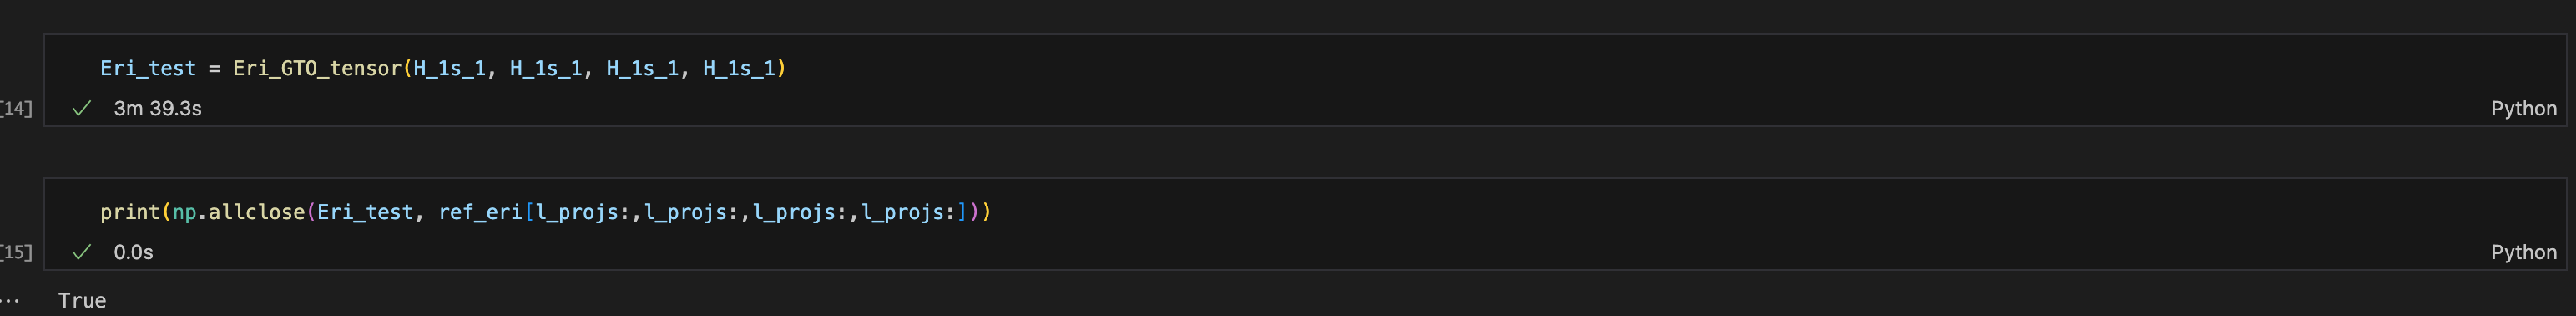

The result for $(22|11)$:

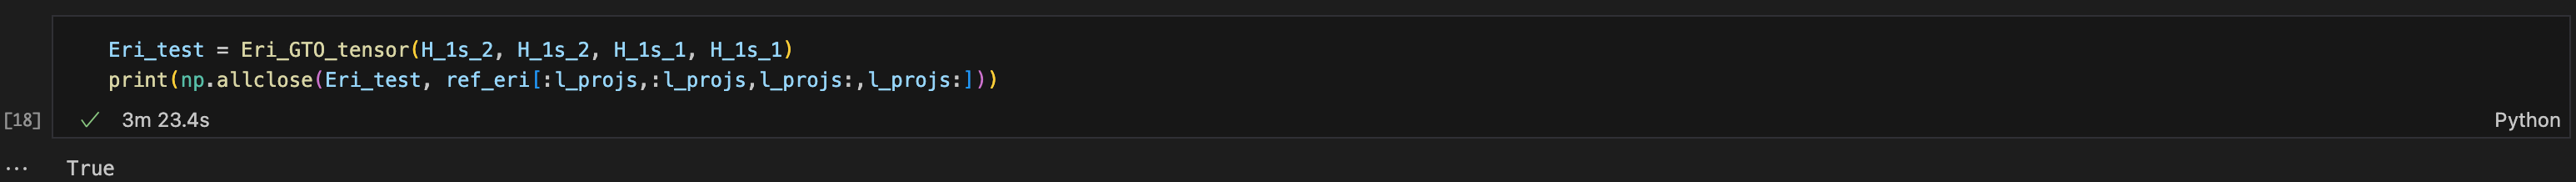

And $(12|11)$

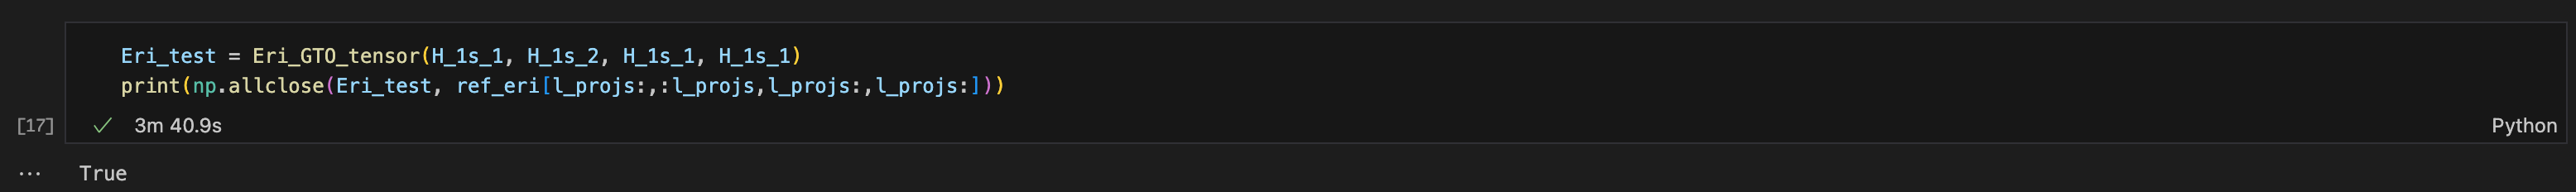

So we know it is working, but the time to beat is roughly 3:40.

Therefore it looks that we are one abstraction layer away from an inefficient but functional integral code. 

---